# Informe piloto — Políticas sociales de infancia en Uruguay

Este informe piloto presenta cuatro métricas en tres temas (violencia
hacia niñas, niños y adolescentes; trabajo infantil; pobreza infantil),
como demostración del estándar del proyecto
[agente-politicas-sociales](https://github.com/testa10/agente-politicas-sociales):
cada métrica se presenta con la pregunta que responde, sus términos, su
gráfica y la justificación del tipo de gráfica elegido, con la fuente
citada en cada caso.

El informe combina los dos bloques globales del proyecto: **análisis
descriptivo** (qué está pasando) y **análisis predictivo** (qué
sucedería si las condiciones actuales persisten).

**Advertencia central de lectura**: las cifras de violencia provienen de
registros administrativos — miden las situaciones que el sistema de
protección detecta y atiende, no cuántos niños sufren violencia en el
país. La nota metodológica del final explica esta diferencia en lenguaje
simple.

## Preparación de datos

Se cargan dos fuentes ya relevadas y documentadas en el repositorio
(`docs/RELEVAMIENTO_DE_DATOS.md`):

- La serie de situaciones atendidas por el SIPIAV, tomada de los doce
  informes de gestión 2013-2024 (INAU) y, para 2023-2024, de las notas
  oficiales de Presidencia e INAU.
- Los microdatos de la Encuesta Continua de Hogares (ECH, INE) de 2024,
  extraídos al universo de 0 a 17 años con sus ponderadores
  (`data/ech/2024/`, generado por `src/extraer_ech_infancia.py`).

Las cifras de trabajo infantil provienen del boletín oficial de la
ENSANNA 2024 (INE/MTSS, con apoyo de OIT y UNICEF), descargado en
`data/ensanna/2024/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if (Path.cwd() / "..").resolve().name == "agente-politicas-sociales" else Path.cwd()
DATOS = (RAIZ / "data") if (RAIZ / "data").exists() else Path("../data")

# Serie SIPIAV: situaciones de violencia hacia NNA atendidas por el
# sistema. Fuente 2013-2022: informes de gestión SIPIAV (texto de cada
# PDF, data/sipiav/<año>/). Fuente 2023 y 2024: notas oficiales
# (Presidencia de la República e INAU), porque en esos PDF el total está
# solo en imagen.
SIPIAV_ANIOS = np.arange(2013, 2025)
SIPIAV_SITUACIONES = np.array(
    [1319, 1728, 1908, 2647, 3155, 4131, 4774, 4911, 7035, 7473, 8157, 8924],
    dtype=float,
)

# ENSANNA 2024, Cuadro 3 ("Trabajo infantil según grupos de edad") y
# Cuadro 1 (total país). Boletín oficial INE:
# data/ensanna/2024/informe_trabajo_infantil_ensanna_2024.html
ENSANNA_GRUPOS = ["5 a 8", "9 a 14", "15 a 17"]
ENSANNA_TASAS = [2.0, 7.6, 10.6]
ENSANNA_TASA_TOTAL = 6.8

# ECH 2024, universo 0-17 con ponderador anual del hogar (W_ANO).
personas_0a17 = pd.read_csv(DATOS / "ech" / "2024" / "personas_0a17.csv")

COLOR = "#2a5674"
COLOR_ACENTO = "#c05555"
plt.rcParams.update({
    "figure.figsize": (9, 4.8),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "figure.dpi": 110,
})

## Tema 1 — Violencia hacia niñas, niños y adolescentes

Este tema mide la **respuesta del sistema de protección**, con datos del
SIPIAV (Sistema Integral de Protección a la Infancia y a la Adolescencia
contra la Violencia, coordinado por INAU e integrado, entre otros, por
MIDES, MSP, ANEP, Fiscalía y Poder Judicial).

Términos utilizados por la fuente:

- **Situación**: cada caso de violencia hacia un NNA detectado,
  registrado e intervenido por el sistema durante el año. Incluye tanto
  casos nuevos como situaciones que continúan de años anteriores.
- **Registro administrativo**: la fuente cuenta lo que el sistema
  atiende, no la totalidad de la violencia existente — un aumento puede
  reflejar mayor capacidad de detección, más denuncia, o más violencia,
  y con el registro solo no es posible distinguirlo.

### 1. Situaciones de violencia atendidas por el sistema, 2013-2024

**¿Qué pregunta responde?** ¿Cómo evolucionó la cantidad de situaciones
de violencia hacia NNA que el sistema de protección detecta y atiende
cada año?

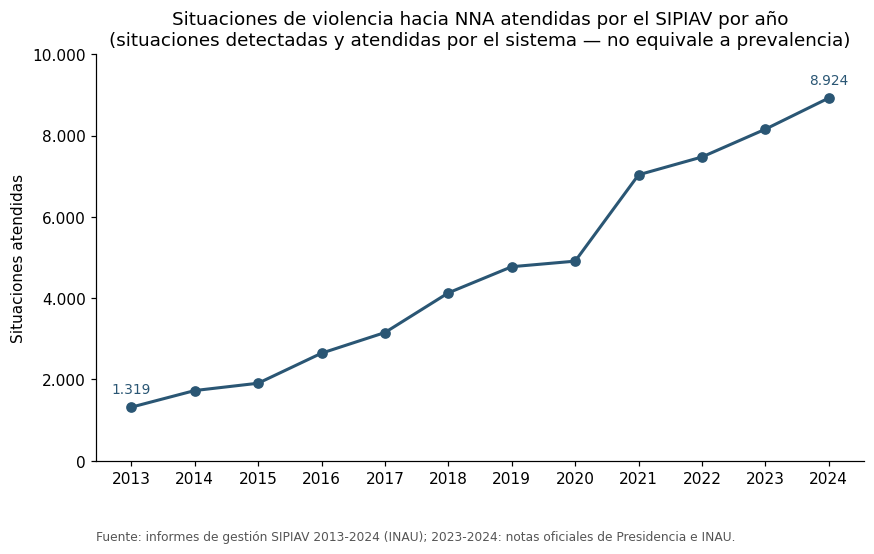

In [2]:
fig, ax = plt.subplots()
ax.plot(SIPIAV_ANIOS, SIPIAV_SITUACIONES, marker="o", color=COLOR, linewidth=2)
ax.set_ylim(0, 10000)
ax.set_xticks(SIPIAV_ANIOS)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", ".")))
ax.set_title(
    "Situaciones de violencia hacia NNA atendidas por el SIPIAV por año\n"
    "(situaciones detectadas y atendidas por el sistema — no equivale a prevalencia)"
)
ax.set_ylabel("Situaciones atendidas")
for x, y in [(2013, 1319), (2024, 8924)]:
    ax.annotate(f"{y:,.0f}".replace(",", "."), (x, y), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=9, color=COLOR)
fig.text(0.125, -0.04,
         "Fuente: informes de gestión SIPIAV 2013-2024 (INAU); 2023-2024: notas oficiales de Presidencia e INAU.",
         fontsize=8, color="#555555")
plt.show()

**Por qué esta gráfica.** Una serie anual de 12 mediciones reales se
representa con línea y marcadores sobre un eje temporal en escala real:
la percepción de posición sobre una escala común es la forma más precisa
de comparación visual (Cleveland y McGill, 1984 — ver
`docs/BIBLIOGRAFIA.md`), y los marcadores distinguen cada medición real
de la interpolación visual entre años (convención heredada de
`docs/CONVENCIONES_DE_GRAFICAS.md`). El eje vertical comienza en cero
para no exagerar visualmente el crecimiento (Healy, 2018).

**Lectura**: las situaciones atendidas se multiplicaron por 6,8 entre
2013 (1.319) y 2024 (8.924). La serie tiene dos saltos con explicación
documental: la incorporación del hospital Pereira Rossell como fuente
(2018-2019) y el efecto pospandemia (2021, +43%). Por tratarse de un
registro administrativo, este crecimiento describe la expansión de la
capacidad de detección y atención del sistema tanto como la evolución
del fenómeno.

### 2. Escenario inercial: situaciones que atendería el sistema en 2025-2027

**¿Qué pregunta responde?** Si la tendencia observada en 2013-2024
continúa sin cambios, ¿cuántas situaciones atendería el sistema en los
próximos años?

**Término propio de esta métrica** — **escenario inercial**: proyección
de la continuación de la tendencia observada, bajo el supuesto explícito
de que las condiciones actuales (capacidad de detección, marco
institucional, contexto social) persisten. No es una predicción de
cuánta violencia habrá: es la trayectoria del propio sistema si nada
cambia.

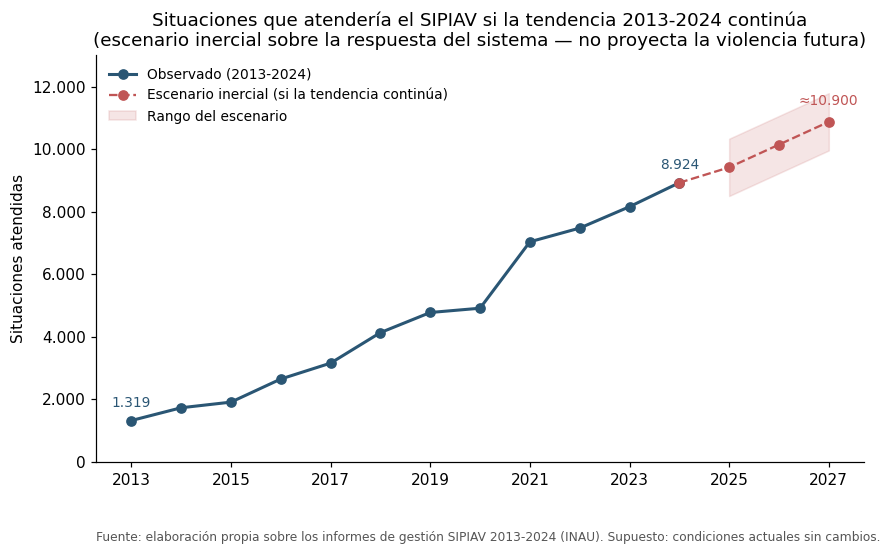

In [3]:
# Escenario inercial: tendencia lineal ajustada sobre la serie completa,
# con rango de +-2 desviaciones estándar de los residuos. La elección
# del método y sus métricas de validación están documentadas para
# público técnico en docs/PREDICTIVO_JUSTIFICACION_TECNICA.md (no
# forman parte de este informe).
coef = np.polyfit(SIPIAV_ANIOS, SIPIAV_SITUACIONES, 1)
residuos = SIPIAV_SITUACIONES - np.polyval(coef, SIPIAV_ANIOS)
s = residuos.std(ddof=2)
anios_fut = np.arange(2025, 2028)
proyeccion = np.polyval(coef, anios_fut)

fig, ax = plt.subplots()
ax.plot(SIPIAV_ANIOS, SIPIAV_SITUACIONES, marker="o", color=COLOR,
        linewidth=2, label="Observado (2013-2024)")
ax.plot(np.append(SIPIAV_ANIOS[-1], anios_fut),
        np.append(SIPIAV_SITUACIONES[-1], proyeccion),
        marker="o", linestyle="--", color=COLOR_ACENTO,
        label="Escenario inercial (si la tendencia continúa)")
ax.fill_between(anios_fut, proyeccion - 2 * s, proyeccion + 2 * s,
                color=COLOR_ACENTO, alpha=0.15, label="Rango del escenario")
ax.set_ylim(0, 13000)
ax.set_xticks(np.arange(2013, 2028, 2))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", ".")))
ax.set_title(
    "Situaciones que atendería el SIPIAV si la tendencia 2013-2024 continúa\n"
    "(escenario inercial sobre la respuesta del sistema — no proyecta la violencia futura)"
)
ax.set_ylabel("Situaciones atendidas")
ax.legend(frameon=False, fontsize=9)
# Convención del proyecto: toda serie anota su primer y último valor, y
# la proyección anota su punto final (ver docs/CONVENCIONES_DE_GRAFICAS.md).
def _fmt(v):
    return f"{v:,.0f}".replace(",", ".")
ax.annotate(_fmt(SIPIAV_SITUACIONES[0]), (SIPIAV_ANIOS[0], SIPIAV_SITUACIONES[0]),
            textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9, color=COLOR)
ax.annotate(_fmt(SIPIAV_SITUACIONES[-1]), (SIPIAV_ANIOS[-1], SIPIAV_SITUACIONES[-1]),
            textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9, color=COLOR)
# El punto proyectado se anota redondeado a centenas y con "≈": la regla
# del bloque predictivo prohíbe sugerir precisión de unidad en una
# proyección (el rango exacto lo da la banda y el texto).
ax.annotate("≈" + _fmt(round(proyeccion[-1], -2)), (anios_fut[-1], proyeccion[-1]),
            textcoords="offset points", xytext=(0, 11), ha="center", fontsize=9, color=COLOR_ACENTO)
fig.text(0.125, -0.04,
         "Fuente: elaboración propia sobre los informes de gestión SIPIAV 2013-2024 (INAU). "
         "Supuesto: condiciones actuales sin cambios.",
         fontsize=8, color="#555555")
plt.show()

**Por qué esta gráfica.** La proyección se muestra como continuación
punteada de la serie observada, con una **banda de rango en lugar de un
número único**: comunicar una proyección como valor puntual sugiere una
precisión que no existe (regla del bloque predictivo,
`docs/METODOLOGIA.md`, sección 3). La distinción visual
observado/proyectado (línea llena con marcadores vs. punteada con banda)
evita que el lector confunda medición con extrapolación — el mismo
principio de Cleveland y McGill aplicado a la honestidad del eje
temporal.

**Lectura**: si la tendencia 2013-2024 continúa, el sistema atendería
aproximadamente entre 8.500 y 10.300 situaciones en 2025, y entre
10.000 y 11.800 en 2027. El informe SIPIAV 2025, ya presentado, permitirá
contrastar este escenario contra el dato real cuando se publique el
total. La justificación técnica del método — dirigida a analistas,
economistas y estadísticos — está en el repositorio y no forma parte de
este informe.

## Tema 2 — Trabajo infantil

Este tema proviene de la **ENSANNA 2024** (Encuesta Nacional sobre las
Actividades de Niñas, Niños y Adolescentes; INE en convenio con el MTSS,
con apoyo de OIT y UNICEF), la única fuente del proyecto que permite
hablar de **prevalencia**: es una encuesta con diseño muestral, no un
registro administrativo.

Términos utilizados por la fuente:

- **Trabajo infantil**: definición estadística alineada con los
  Convenios 138 y 182 de la OIT; incluye actividades económicas y
  trabajo no remunerado de servicios en condiciones no permitidas para
  la edad. El universo de la encuesta son los NNA de 5 a 17 años.

### 3. Trabajo infantil por grupo de edad, 2024

**¿Qué pregunta responde?** ¿Qué proporción de NNA está en situación de
trabajo infantil y cómo cambia con la edad?

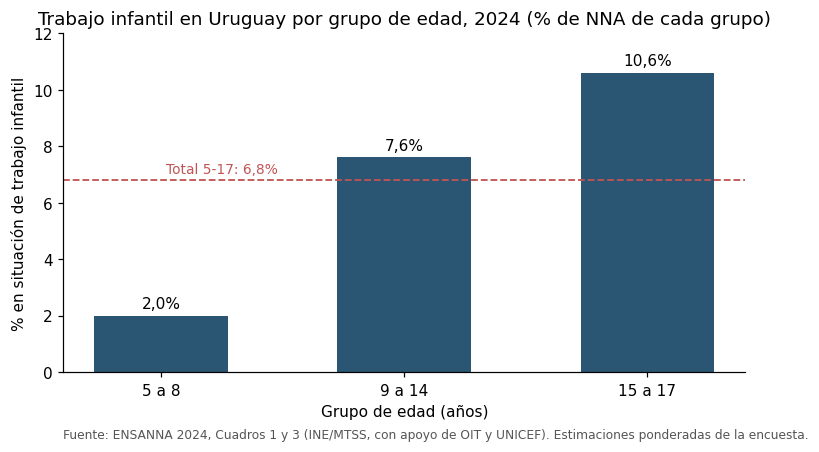

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
barras = ax.bar(ENSANNA_GRUPOS, ENSANNA_TASAS, color=COLOR, width=0.55)
ax.axhline(ENSANNA_TASA_TOTAL, color=COLOR_ACENTO, linewidth=1.2, linestyle="--")
ax.annotate(f"Total 5-17: {str(ENSANNA_TASA_TOTAL).replace('.', ',')}%",
            (0.02, ENSANNA_TASA_TOTAL + 0.25), fontsize=9, color=COLOR_ACENTO)
ax.bar_label(barras, labels=[str(t).replace(".", ",") + "%" for t in ENSANNA_TASAS],
             padding=3, fontsize=10)
ax.set_ylim(0, 12)
ax.set_title("Trabajo infantil en Uruguay por grupo de edad, 2024 (% de NNA de cada grupo)")
ax.set_ylabel("% en situación de trabajo infantil")
ax.set_xlabel("Grupo de edad (años)")
fig.text(0.125, -0.04,
         "Fuente: ENSANNA 2024, Cuadros 1 y 3 (INE/MTSS, con apoyo de OIT y UNICEF). Estimaciones ponderadas de la encuesta.",
         fontsize=8, color="#555555")
plt.show()

**Por qué esta gráfica.** Barras verticales para comparar una misma
medida entre pocas categorías ordinales (tres grupos de edad, en su
orden natural): la comparación directa de longitudes desde una base
común es la forma más precisa de percepción visual de magnitudes
(Cleveland y McGill, 1984; Few, *Show Me the Numbers*). El eje comienza
en cero (Healy, 2018) y la línea de referencia del total permite ubicar
cada grupo respecto del promedio sin agregar tinta innecesaria (Tufte,
principio de data-ink).

**Lectura**: 6,8% de los NNA de 5 a 17 años — más de 40.000 — está en
situación de trabajo infantil, y la tasa crece con la edad hasta
alcanzar 10,6% entre los 15 y 17 años. A diferencia del tema anterior,
estas cifras sí son prevalencia: describen a la población, no a los
casos que un sistema detecta.

## Tema 3 — Pobreza infantil

Este tema se calcula directamente sobre los **microdatos de la ECH 2024**
(INE), extraídos al universo de 0 a 17 años. Toda estimación está
ponderada por el ponderador anual del hogar (`W_ANO`).

Términos utilizados:

- **Pobreza monetaria**: clasificación oficial del INE (metodología de
  canasta 2017, variable `pobre17`): hogares cuyo ingreso no alcanza la
  línea de pobreza. Un NNA es pobre si vive en un hogar pobre.
- **Tramos de edad**: se usan los tramos del SIPIAV (0-5, 6-12, 13-17)
  para que este resultado sea directamente comparable con el Tema 1
  (ver `docs/CLASIFICACION_DE_EDADES.md`).
- **Estimación ponderada**: cada persona de la muestra representa a un
  número distinto de personas de la población; los porcentajes se
  calculan con esa expansión, nunca como proporción simple de la
  muestra.

### 4. Pobreza monetaria en la infancia por tramo de edad, 2024

**¿Qué pregunta responde?** ¿Qué proporción de NNA vive en hogares en
situación de pobreza, y afecta por igual a todas las edades?

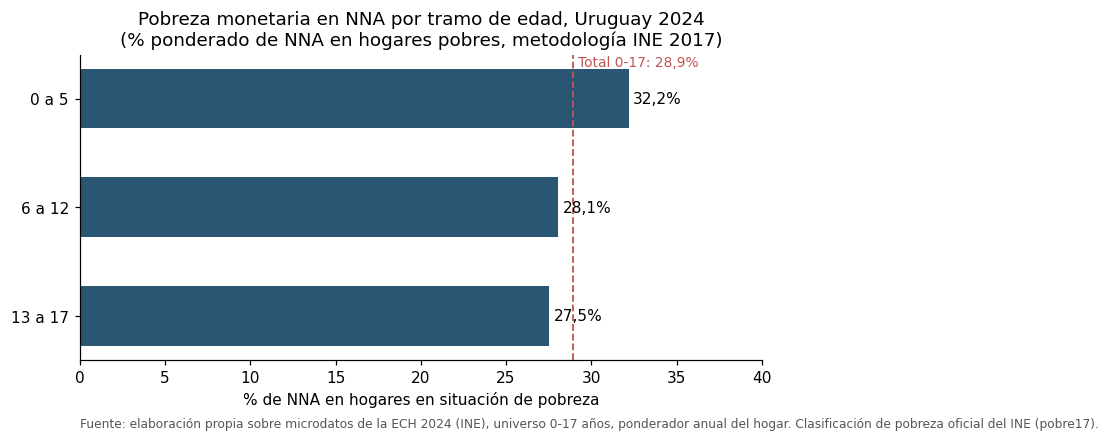

In [5]:
def pct_ponderado(df: pd.DataFrame) -> float:
    return (df["pobre"] * df["ponderador_hogar"]).sum() / df["ponderador_hogar"].sum() * 100

tramos = ["0 a 5", "6 a 12", "13 a 17"]
pobreza = [pct_ponderado(personas_0a17[personas_0a17["tramo_sipiav"] == t]) for t in tramos]
pobreza_total = pct_ponderado(personas_0a17)

fig, ax = plt.subplots(figsize=(8, 3.6))
barras = ax.barh(tramos[::-1], pobreza[::-1], color=COLOR, height=0.55)
ax.axvline(pobreza_total, color=COLOR_ACENTO, linewidth=1.2, linestyle="--")
ax.annotate(f"Total 0-17: {pobreza_total:.1f}%".replace(".", ","),
            (pobreza_total + 0.3, 2.30), fontsize=9, color=COLOR_ACENTO)
ax.bar_label(barras, labels=[f"{v:.1f}%".replace(".", ",") for v in pobreza[::-1]],
             padding=3, fontsize=10)
ax.set_xlim(0, 40)
ax.set_title("Pobreza monetaria en NNA por tramo de edad, Uruguay 2024\n(% ponderado de NNA en hogares pobres, metodología INE 2017)")
ax.set_xlabel("% de NNA en hogares en situación de pobreza")
fig.text(0.125, -0.06,
         "Fuente: elaboración propia sobre microdatos de la ECH 2024 (INE), universo 0-17 años, "
         "ponderador anual del hogar. Clasificación de pobreza oficial del INE (pobre17).",
         fontsize=8, color="#555555")
plt.show()

**Por qué esta gráfica.** Barras horizontales para categorías con
etiquetas legibles sin inclinar la cabeza (Cleveland y McGill, 1984,
sobre precisión de posición y longitud), presentadas en el **orden
etario natural** y no ordenadas por valor: los tramos son una secuencia
ordinal y romper esa secuencia dificultaría la lectura del patrón por
edad (principio Gestalt de continuidad — Ware). El eje comienza en cero
(Healy, 2018) y la línea de referencia marca el total del universo 0-17.

**Lectura**: en 2024, el 28,9% de los NNA vivía en hogares en situación
de pobreza — y el patrón por edad es regresivo con la primera infancia:
cuanto más pequeños, mayor la incidencia (32,2% entre 0 y 5 años frente
a 27,5% entre 13 y 17). Como referencia externa, la pobreza en la
población general que publica el INE ronda niveles muy inferiores: la
pobreza en Uruguay está concentrada en la infancia.

## Nota metodológica

**Qué significa "ponderado".** Las cifras de la ECH y de la ENSANNA no
son porcentajes simples de las personas encuestadas: cada hogar de la
muestra representa a un número distinto de hogares del país, según el
diseño de la encuesta. Los porcentajes de este informe usan esa
expansión (el "ponderador"), que es la forma correcta de estimar valores
para toda la población.

**Registros administrativos y prevalencia.** Las cifras del SIPIAV
cuentan las situaciones que el sistema de protección detecta y atiende.
No existe una medición de cuántos NNA sufren violencia en Uruguay (eso
requeriría una encuesta de prevalencia). Por eso este informe nunca
convierte cifras del SIPIAV en frases como "la violencia aumentó": lo
que se observa es el crecimiento de la respuesta del sistema.

**Escenario inercial.** La única proyección de este informe describe qué
sucedería **si las condiciones actuales persisten**, con un rango de
incertidumbre. No es una predicción: es la trayectoria implícita en los
datos observados, útil para dimensionar la demanda futura del sistema si
nada cambia.

## Resumen analítico

**Violencia hacia NNA.** El sistema de protección atendió 8.924
situaciones de violencia hacia niñas, niños y adolescentes en 2024 — un
promedio de 24 por día, y 6,8 veces las 1.319 situaciones de 2013. Si la
tendencia de estos doce años continúa, el sistema atendería entre 8.500
y 10.300 situaciones en 2025, y entre 10.000 y 11.800 en 2027. Estas
cifras describen la respuesta del sistema, no la magnitud total de la
violencia.

**Trabajo infantil.** El 6,8% de los NNA de 5 a 17 años — más de
40.000 — está en situación de trabajo infantil según la ENSANNA 2024, y
la incidencia crece con la edad: 10,6% entre los 15 y 17 años.

**Pobreza infantil.** El 28,9% de los NNA vivía en hogares en situación
de pobreza en 2024, con un patrón regresivo con la edad: la incidencia
más alta está en la primera infancia (32,2% entre 0 y 5 años). La
pobreza en Uruguay tiene rostro de infancia.

## Conclusiones

1. **La pobreza uruguaya está concentrada en la infancia, y dentro de la
   infancia, en sus edades más tempranas.** Casi tres de cada diez NNA
   viven en hogares pobres (28,9% en 2024), y la incidencia es mayor
   cuanto menor es la edad (32,2% entre 0 y 5 años frente a 27,5% entre
   13 y 17). Dado que la primera infancia es la etapa de mayor
   sensibilidad del desarrollo, este patrón regresivo constituye el dato
   más relevante del informe para el diseño de políticas (fuente:
   elaboración propia sobre microdatos ECH 2024, INE).

2. **La respuesta del sistema de protección contra la violencia crece de
   forma sostenida y sin señales de estabilización.** Las situaciones
   atendidas se multiplicaron por 6,8 en doce años y, en el escenario
   inercial, el sistema atendería entre 10.000 y 11.800 situaciones
   anuales hacia 2027. Con registros administrativos no es posible
   separar cuánto de ese crecimiento es mayor detección y cuánto es
   mayor incidencia — distinguirlo requeriría una **encuesta de
   prevalencia de violencia hacia NNA**, que Uruguay no tiene: esa es la
   brecha de información más importante que este informe identifica
   (fuente: informes de gestión SIPIAV 2013-2024, INAU).

3. **El trabajo infantil persiste con un claro gradiente etario y
   socioeconómico.** Afecta al 6,8% de los NNA (más de 40.000), crece
   con la edad hasta 10,6% entre los 15 y 17 años, y es mayor en el
   interior y en los niveles socioeconómicos más bajos (fuente: ENSANNA
   2024, INE/MTSS).

4. **Limitaciones de este informe piloto**, declaradas para su
   evaluación experta: (a) las cifras de violencia describen la
   respuesta del sistema, no la prevalencia del fenómeno; (b) la única
   proyección incluida es un escenario inercial con supuesto explícito,
   no un pronóstico; (c) los microdatos de la ENSANNA 2024 aún no son
   públicos, por lo que el tema trabajo infantil se limita a los cuadros
   del boletín oficial; (d) el SIPIAV no publica desagregación
   departamental de situaciones, lo que impide por ahora el análisis
   territorial de la violencia. La agenda inmediata del proyecto —
   cruces departamentales entre protección especial (INAU) y condiciones
   socioeconómicas de la infancia (ECH) — está documentada en el
   repositorio.

---

*Informe piloto generado por el proyecto*
[agente-politicas-sociales](https://github.com/testa10/agente-politicas-sociales)
*— las fuentes completas de cada cifra están citadas en cada sección y
en `docs/BIBLIOGRAFIA.md`.*